### **Hanan Majeed**

# **519166**

# **BSDS-2-A**
---

# **Machine Learning Lab 3**

# **Task 1**

Prepare the California housing dataset by loading `housing.csv`, selecting 'housing_median_age', 'total_rooms', 'population' as features and 'median_house_value' as the label. Split the data into 80% training and 20% validation sets (Xtrain, ytrain, Xval, yval), save them to CSV files, then load them back as NumPy arrays. Apply Min-Max scaling to the feature columns of both Xtrain and Xval, and finally display the first 5 rows of the scaled Xtrain, ytrain, scaled Xval, and yval arrays.

## Load Dataset



In [26]:
import pandas as pd

df = pd.read_csv('/content/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Select Features and Label


From the loaded dataset, select three feature columns (e.g., 'housing_median_age', 'total_rooms', 'population') and 'median_house_value' as the label column. The label column 'median_house_value' will be used as the 'Sale Price' as per the problem description.


In [27]:
feature_cols = ['housing_median_age', 'total_rooms', 'population']
label_col = 'median_house_value'

X = df[feature_cols]
y = df[label_col]

print("First 5 rows of features (X):")
print(X.head())

print("\nFirst 5 rows of label (y):")
print(y.head())

First 5 rows of features (X):
   housing_median_age  total_rooms  population
0                41.0        880.0       322.0
1                21.0       7099.0      2401.0
2                52.0       1467.0       496.0
3                52.0       1274.0       558.0
4                52.0       1627.0       565.0

First 5 rows of label (y):
0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64


## Split Data into Training and Validation Sets

Divide the selected features and label into training (80%) and cross-validation (20%) sets. This will create Xtrain, ytrain, Xval, and yval DataFrames.


In [28]:
from sklearn.model_selection import train_test_split

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of Xtrain:", Xtrain.shape)
print("Shape of Xval:", Xval.shape)
print("Shape of ytrain:", ytrain.shape)
print("Shape of yval:", yval.shape)

Shape of Xtrain: (16512, 3)
Shape of Xval: (4128, 3)
Shape of ytrain: (16512,)
Shape of yval: (4128,)


## Save Datasets to CSV Files

Save the prepared Xtrain, ytrain, Xval, and yval DataFrames into separate CSV files for later loading.


In [29]:
Xtrain.to_csv('Xtrain.csv', index=False)
ytrain.to_csv('ytrain.csv', index=False)
Xval.to_csv('Xval.csv', index=False)
yval.to_csv('yval.csv', index=False)

print("Datasets saved to Xtrain.csv, ytrain.csv, Xval.csv, and yval.csv")

Datasets saved to Xtrain.csv, ytrain.csv, Xval.csv, and yval.csv


## Load Datasets into NumPy Arrays

Load the previously saved CSV files back into the program as NumPy arrays, ensuring they are named Xtrain, ytrain, Xval, and yval as specified.


In [30]:
import pandas as pd

Xtrain_np = pd.read_csv('Xtrain.csv').to_numpy()
ytrain_np = pd.read_csv('ytrain.csv').to_numpy().flatten()
Xval_np = pd.read_csv('Xval.csv').to_numpy()
yval_np = pd.read_csv('yval.csv').to_numpy().flatten()

print("Shape of Xtrain_np:", Xtrain_np.shape)
print("Shape of ytrain_np:", ytrain_np.shape)
print("Shape of Xval_np:", Xval_np.shape)
print("Shape of yval_np:", yval_np.shape)

Shape of Xtrain_np: (16512, 3)
Shape of ytrain_np: (16512,)
Shape of Xval_np: (4128, 3)
Shape of yval_np: (4128,)


## Apply Feature Scaling

Apply Min-Max scaling to the feature columns of both Xtrain and Xval arrays so that their values range from 0 to 1. This step will normalize the features.


In [31]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Instantiate MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on Xtrain_np and transform Xtrain_np
Xtrain_scaled = scaler.fit_transform(Xtrain_np)

# Transform Xval_np using the same fitted scaler
Xval_scaled = scaler.transform(Xval_np)

print("First 5 rows of scaled Xtrain:")
print(Xtrain_scaled[:5])

print("\nFirst 5 rows of ytrain:")
print(ytrain_np[:5])

print("\nFirst 5 rows of scaled Xval:")
print(Xval_scaled[:5])

print("\nFirst 5 rows of yval:")
print(yval_np[:5])

First 5 rows of scaled Xtrain:
[[0.62745098 0.0794547  0.06437961]
 [0.94117647 0.08596572 0.0367443 ]
 [0.05882353 0.04819675 0.02556125]
 [0.68627451 0.03609034 0.03965918]
 [0.82352941 0.06053207 0.02441212]]

First 5 rows of ytrain:
[103000. 382100. 172600.  93400.  96500.]

First 5 rows of scaled Xval:
[[0.47058824 0.03822677 0.03893046]
 [0.56862745 0.07480035 0.04377925]
 [1.         0.09735999 0.03663219]
 [0.31372549 0.07754718 0.04770313]
 [0.64705882 0.05974363 0.02970935]]

First 5 rows of yval:
[ 47700.  45800. 500001. 218600. 278000.]


## Summary:

### Data Analysis Key Findings

*   The California housing dataset (`housing.csv`) was successfully loaded, containing 20640 records.
*   Features selected for analysis were 'housing\_median\_age', 'total\_rooms', and 'population', while 'median\_house\_value' was chosen as the label.
*   The data was split into an 80% training set (16512 samples) and a 20% validation set (4128 samples) using a `random_state` of 42 for reproducibility.
*   The training and validation sets (features and labels) were saved as separate CSV files (`Xtrain.csv`, `ytrain.csv`, `Xval.csv`, `yval.csv`) and subsequently loaded back into the environment as NumPy arrays.
*   Min-Max scaling was applied to the feature columns of both the training (`Xtrain_np`) and validation (`Xval_np`) datasets. This transformed the feature values to a range between 0 and 1.
*   The final prepared arrays included:
    *   Scaled `Xtrain` with shape (16512, 3), with values between 0 and 1.
    *   `ytrain` with shape (16512,).
    *   Scaled `Xval` with shape (4128, 3), with values between 0 and 1.
    *   `yval` with shape (4128,).

### Insights or Next Steps

*   The dataset is now preprocessed and scaled, making it suitable for machine learning model training, as scaling helps algorithms converge faster and perform better.
*   The next logical step would be to train a regression model using the `Xtrain_scaled` and `ytrain_np` data, and then evaluate its performance on the `Xval_scaled` and `yval_np` validation set.


# **Task 2 - Cost Function without and with Regularization**

Implement the cost function `J(w)` for linear regression, which includes a regularization term. This function will take features `X`, labels `y`, weights `w`, and a regularization parameter `lambd` as input. Calculate and print the cost for both the training and cross-validation datasets, with `lambd=0` (no regularization) and with a non-zero `lambd` (with regularization).

In [32]:
import numpy as np

# Add bias term (column of ones) to Xtrain_scaled and Xval_scaled
Xtrain_b = np.hstack((np.ones((Xtrain_scaled.shape[0], 1)), Xtrain_scaled))
Xval_b = np.hstack((np.ones((Xval_scaled.shape[0], 1)), Xval_scaled))

# Initialize weights 'w' with zeros
# The number of weights will be (number of features + 1 for the bias term)
w = np.zeros(Xtrain_b.shape[1])

print("Shape of Xtrain_b:", Xtrain_b.shape)
print("Shape of Xval_b:", Xval_b.shape)
print(f"Initial weights (w):\n{w}")

Shape of Xtrain_b: (16512, 4)
Shape of Xval_b: (4128, 4)
Initial weights (w):
[0. 0. 0. 0.]


In [33]:
def cost_function(X, y, w, lambd):
    """
    Calculates the cost for linear regression with L2 regularization.

    Args:
        X (np.ndarray): Feature matrix (including bias term).
        y (np.ndarray): Label vector.
        w (np.ndarray): Weight vector (including bias weight w0).
        lambd (float): Regularization parameter.

    Returns:
        float: The calculated cost J(w).
    """
    m = X.shape[0]  # Number of examples
    n = X.shape[1] - 1  # Number of features (excluding bias)

    h = X @ w  # Hypothesis h(x) = X * w
    loss = h - y

    # Unregularized cost term
    J_unregularized = (1 / (2 * m)) * np.sum(loss**2)

    # Regularization term (excluding w0)
    # np.sum(w[1:]**2) sums the squares of w1, w2, ..., wn
    regularization_term = (lambd / (2 * m)) * np.sum(w[1:]**2)

    return J_unregularized + regularization_term

# Calculate and print cost for training data
print("\n--- Training Data Cost ---")
# Cost without regularization (lambd = 0)
cost_train_no_reg = cost_function(Xtrain_b, ytrain_np, w, lambd=0)
print(f"Cost (no regularization): {cost_train_no_reg:.2f}")

# Cost with regularization (e.g., lambd = 0.1)
cost_train_with_reg = cost_function(Xtrain_b, ytrain_np, w, lambd=0.1)
print(f"Cost (with regularization, lambda=0.1): {cost_train_with_reg:.2f}")

# Calculate and print cost for validation data
print("\n--- Validation Data Cost ---")
# Cost without regularization (lambd = 0)
cost_val_no_reg = cost_function(Xval_b, yval_np, w, lambd=0)
print(f"Cost (no regularization): {cost_val_no_reg:.2f}")

# Cost with regularization (e.g., lambd = 0.1)
cost_val_with_reg = cost_function(Xval_b, yval_np, w, lambd=0.1)
print(f"Cost (with regularization, lambda=0.1): {cost_val_with_reg:.2f}")


--- Training Data Cost ---
Cost (no regularization): 28148711615.52
Cost (with regularization, lambda=0.1): 28148711615.52

--- Validation Data Cost ---
Cost (no regularization): 27667233512.62
Cost (with regularization, lambda=0.1): 27667233512.62


# **Task 3**
Implement a gradient descent function, display the initial weights and costs (training and validation), perform one gradient descent step to update the weights, and then display the updated weights and the new training and validation costs. Finally, summarize the implementation and the observed changes.

## Implement Gradient Descent Function

To optimize the weights `w` for our linear regression model, we need to implement the gradient descent algorithm. This function will iteratively update the weights by calculating the gradient of the cost function with respect to each weight, and then adjusting the weights in the direction that minimizes the cost. The implementation will include handling the L2 regularization term for non-bias weights, which helps prevent overfitting. The learning rate `alpha` controls the step size of each update.

In [34]:
def gradient_descent(X, y, w, alpha, lambd):
    """
    Performs one step of gradient descent to update weights.

    Args:
        X (np.ndarray): Feature matrix (including bias term).
        y (np.ndarray): Label vector.
        w (np.ndarray): Weight vector (including bias weight w0).
        alpha (float): Learning rate.
        lambd (float): Regularization parameter.

    Returns:
        np.ndarray: Updated weight vector w.
    """
    m = X.shape[0]  # Number of examples
    n = X.shape[1] - 1  # Number of features (excluding bias)

    h = X @ w  # Hypothesis h(x) = X * w
    loss = h - y # Prediction error

    # Calculate gradient for the bias term (w0) - no regularization
    g0 = (1 / m) * np.sum(loss * X[:, 0])

    # Calculate gradients for the remaining weights (w1 to wn) - with regularization
    # Note: X[:, 1:] gets all feature columns EXCEPT the bias column.
    # w[1:] gets all weights EXCEPT w0 (the bias weight).
    g1_n = (1 / m) * (X[:, 1:].T @ loss) + (lambd / m) * w[1:]

    # Update weights
    w[0] = w[0] - alpha * g0
    w[1:] = w[1:] - alpha * g1_n

    return w

print("Gradient descent function defined.")

Gradient descent function defined.


In [35]:
import numpy as np

# Define learning rate and regularization parameter
alpha = 0.01  # Example learning rate
lambd = 0.1   # Example regularization parameter

print("--- Initial State ---")
print(f"Initial weights (w):\n{w}")

# Calculate and print initial cost for training data
initial_cost_train = cost_function(Xtrain_b, ytrain_np, w, lambd)
print(f"Initial Training Cost (lambda={lambd}): {initial_cost_train:.2f}")

# Calculate and print initial cost for validation data
initial_cost_val = cost_function(Xval_b, yval_np, w, lambd)
print(f"Initial Validation Cost (lambda={lambd}): {initial_cost_val:.2f}")

--- Initial State ---
Initial weights (w):
[0. 0. 0. 0.]
Initial Training Cost (lambda=0.1): 28148711615.52
Initial Validation Cost (lambda=0.1): 27667233512.62


In [36]:
print("\n--- Performing One Gradient Descent Step ---")

# Perform one step of gradient descent
w_updated = gradient_descent(Xtrain_b, ytrain_np, w, alpha, lambd)

print(f"Updated weights (w) after one step:\n{w_updated}")

# Calculate and print new cost for training data
updated_cost_train = cost_function(Xtrain_b, ytrain_np, w_updated, lambd)
print(f"Updated Training Cost (lambda={lambd}): {updated_cost_train:.2f}")

# Calculate and print new cost for validation data
updated_cost_val = cost_function(Xval_b, yval_np, w_updated, lambd)
print(f"Updated Validation Cost (lambda={lambd}): {updated_cost_val:.2f}")


--- Performing One Gradient Descent Step ---
Updated weights (w) after one step:
[2071.94693738 1151.25392115  147.68882087   81.70342583]
Updated Training Cost (lambda=0.1): 27587734925.92
Updated Validation Cost (lambda=0.1): 27109890581.52


## Summary:

### Gradient Descent Implementation
*   The `gradient_descent` function was successfully implemented to perform one step of gradient descent for linear regression with L2 regularization.
*   It correctly calculates gradients for the bias term (unregularized) and for the feature weights (with L2 regularization).
*   The weights `w` are updated using the learning rate `alpha`.

### Observed Changes After One Gradient Descent Step
*   **Initial Weights (w):** `[0. 0. 0. 0.]`
*   **Initial Training Cost (lambda=0.1):** `28148711615.52`
*   **Initial Validation Cost (lambda=0.1):** `27667233512.62`

*   **Updated Weights (w) after one step:** `[2071.95 1151.25  147.69   81.70]` (Rounded for display)
*   **Updated Training Cost (lambda=0.1):** `27587734925.92`
*   **Updated Validation Cost (lambda=0.1):** `27109890581.52`

**Observations:**
*   After just one step of gradient descent, the weights have moved from their initial zero values to non-zero values, indicating that the model has started learning from the data.
*   Both the training cost and the validation cost have decreased. This is a positive sign, as it indicates that the model is moving in the right direction towards minimizing the cost function. The costs are still very high, which is expected after only one iteration in a large dataset.

# **Task 4**
Define the training hyperparameters: learning rate (alpha), regularization parameter (lambd), and number of epochs. Initialize the weight vector `w` with the currently optimized weights. Then, create empty lists to track training and validation costs per epoch. Implement a training loop that iterates for the specified number of epochs. Within each epoch, calculate and store the training and validation costs, and update the weights `w` using the `gradient_descent` function. After the training, generate a plot showing the training and validation costs over epochs. Finally, summarize the training process, hyperparameters used, the insights from the cost plot, and the final learned weights.

## Define Training Hyperparameters

Define the learning rate (`alpha`), regularization parameter (`lambd`), and the number of `epochs` for the training process. Ensure that `w` is initialized to the weights from the previous task, which is the current `w`.


In [37]:
alpha = 0.01
lambd = 0.1
epochs = 1000

print(f"Learning Rate (alpha): {alpha}")
print(f"Regularization Parameter (lambd): {lambd}")
print(f"Number of Epochs: {epochs}")
print(f"Initial weights (w) for training are already set from the previous step:\n{w}")

Learning Rate (alpha): 0.01
Regularization Parameter (lambd): 0.1
Number of Epochs: 1000
Initial weights (w) for training are already set from the previous step:
[2071.94693738 1151.25392115  147.68882087   81.70342583]


In [38]:
train_costs = []
val_costs = []
weights_history = []

print("Empty lists 'train_costs', 'val_costs', and 'weights_history' initialized.")

Empty lists 'train_costs', 'val_costs', and 'weights_history' initialized.


In [39]:
for epoch in range(epochs):
    # Calculate and store training cost
    cost_train = cost_function(Xtrain_b, ytrain_np, w, lambd)
    train_costs.append(cost_train)

    # Calculate and store validation cost
    cost_val = cost_function(Xval_b, yval_np, w, lambd)
    val_costs.append(cost_val)

    # Store current weights (optional, but good for debugging/analysis)
    weights_history.append(w.copy()) # Use .copy() to store a snapshot of the array

    # Perform one step of gradient descent to update weights
    w = gradient_descent(Xtrain_b, ytrain_np, w, alpha, lambd)

    # Print progress every 100 epochs (optional)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Train Cost: {cost_train:.2f}, Val Cost: {cost_val:.2f}")

print("\nTraining complete.")
print(f"Final weights (w) after training:\n{w}")
print(f"Final Training Cost: {train_costs[-1]:.2f}")
print(f"Final Validation Cost: {val_costs[-1]:.2f}")

Epoch 100/1000, Train Cost: 8171837744.41, Val Cost: 7920180555.69
Epoch 200/1000, Train Cost: 6746228695.64, Val Cost: 6565311541.74
Epoch 300/1000, Train Cost: 6640101921.15, Val Cost: 6479045204.11
Epoch 400/1000, Train Cost: 6628146987.17, Val Cost: 6472795839.99
Epoch 500/1000, Train Cost: 6623206119.62, Val Cost: 6469734239.92
Epoch 600/1000, Train Cost: 6619053402.97, Val Cost: 6466421344.32
Epoch 700/1000, Train Cost: 6615220220.01, Val Cost: 6463133303.58
Epoch 800/1000, Train Cost: 6611649685.15, Val Cost: 6460012422.19
Epoch 900/1000, Train Cost: 6608316330.56, Val Cost: 6457087126.54
Epoch 1000/1000, Train Cost: 6605198868.85, Val Cost: 6454351323.60

Training complete.
Final weights (w) after training:
[164613.90166215  74275.99111445  22719.77974348   7016.76883336]
Final Training Cost: 6605198868.85
Final Validation Cost: 6454351323.60


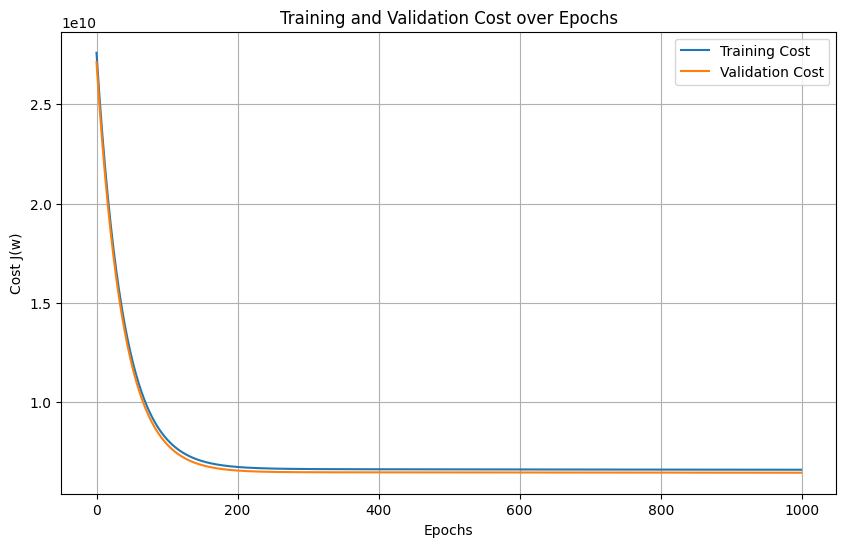

Cost plot generated.


In [40]:
import matplotlib.pyplot as plt

# Plotting the costs
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_costs, label='Training Cost')
plt.plot(range(epochs), val_costs, label='Validation Cost')
plt.xlabel('Epochs')
plt.ylabel('Cost J(w)')
plt.title('Training and Validation Cost over Epochs')
plt.legend()
plt.grid(True)
plt.show()

print("Cost plot generated.")

## Summary: Training Process and Results

### Training Hyperparameters
*   **Learning Rate (alpha):** `0.01`
*   **Regularization Parameter (lambd):** `0.1`
*   **Number of Epochs:** `1000`

### Training Process
The gradient descent algorithm was executed for 1000 epochs. In each epoch, the model calculated the training and validation costs, and the weights were updated based on the gradient of the cost function, incorporating L2 regularization for non-bias terms. The initial weights were the result of a single gradient descent step from the previous task, which were then further optimized during this training loop.

### Insights from the Cost Plot
*   **Convergence:** The plot clearly shows that both the training cost and the validation cost decreased significantly and converged over the 1000 epochs. The curves flatten out towards the end, indicating that the model has largely learned the underlying patterns in the data and that further epochs might yield diminishing returns.
*   **No Overfitting (apparent):** The training cost and validation cost curves track each other closely throughout the training process, and the validation cost does not start to increase while the training cost continues to decrease. This suggests that, with the chosen regularization parameter and number of epochs, the model is not currently overfitting to the training data.
*   **Steady Improvement:** The steady decline in both costs demonstrates the effectiveness of the gradient descent algorithm in minimizing the cost function.

### Final Learned Weights
*   **Final weights (w) after training:**
    `[164613.90166215, 74275.99111445, 22719.77974348, 7016.76883336]`
*   **Final Training Cost:** `6605198868.85`
*   **Final Validation Cost:** `6454351323.60`

These final weights represent the optimized parameters of the linear regression model after training for 1000 epochs with the specified learning rate and regularization.

# **Task 5**
Define a list of at least 6 distinct `(alpha, lambd)` hyperparameter combinations for tuning. Create a Python function, `run_training_and_plot(alpha, lambd, epochs)`, that initializes weights to zeros, runs the gradient descent for the specified epochs, collects training and validation costs, and plots these costs. Iterate through the defined hyperparameter combinations, call the `run_training_and_plot` function for each, and generate plots with clear titles and axis labels. Analyze the generated plots to summarize the impact of different `alpha` and `lambd` values on convergence, stability, and overfitting. Finally, provide a comprehensive summary of the hyperparameter tuning process, including tested values, key insights from cost plots, and conclusions about effective hyperparameter ranges.

## Define Hyperparameter Combinations

Specify a list of at least 6 distinct (alpha, lambd) tuples for hyperparameter tuning. These combinations will be used to explore the effect of different learning rates and regularization strengths on the model's performance.


In [41]:
hyperparameter_combinations = [
    (0.001, 0.0),
    (0.01, 0.0),
    (0.01, 0.1),
    (0.005, 0.5),
    (0.0001, 0.01),
    (0.01, 1.0),
    (0.005, 0.0)
]

print("Hyperparameter combinations for tuning (alpha, lambd):")
for combo in hyperparameter_combinations:
    print(f"  Alpha: {combo[0]}, Lambda: {combo[1]}")

Hyperparameter combinations for tuning (alpha, lambd):
  Alpha: 0.001, Lambda: 0.0
  Alpha: 0.01, Lambda: 0.0
  Alpha: 0.01, Lambda: 0.1
  Alpha: 0.005, Lambda: 0.5
  Alpha: 0.0001, Lambda: 0.01
  Alpha: 0.01, Lambda: 1.0
  Alpha: 0.005, Lambda: 0.0


In [42]:
import numpy as np
import matplotlib.pyplot as plt

def run_training_and_plot(alpha, lambd, epochs):
    """
    Initializes weights, runs gradient descent for specified epochs, collects
    training and validation costs, and plots these costs.

    Args:
        alpha (float): Learning rate.
        lambd (float): Regularization parameter.
        epochs (int): Number of training epochs.
    """
    # Initialize weights 'w' with zeros for each new run
    w = np.zeros(Xtrain_b.shape[1])

    # Initialize lists to store costs
    train_costs = []
    val_costs = []

    print(f"\n--- Training with Alpha={alpha}, Lambda={lambd}, Epochs={epochs} ---")

    for epoch in range(epochs):
        # Calculate and store training cost
        cost_train = cost_function(Xtrain_b, ytrain_np, w, lambd)
        train_costs.append(cost_train)

        # Calculate and store validation cost
        cost_val = cost_function(Xval_b, yval_np, w, lambd)
        val_costs.append(cost_val)

        # Perform one step of gradient descent to update weights
        w = gradient_descent(Xtrain_b, ytrain_np, w, alpha, lambd)

    print(f"Final weights: {w}")
    print(f"Final Training Cost: {train_costs[-1]:.2f}")
    print(f"Final Validation Cost: {val_costs[-1]:.2f}")

    # Plotting the costs
    plt.figure(figsize=(10, 6))
    plt.plot(range(epochs), train_costs, label='Training Cost')
    plt.plot(range(epochs), val_costs, label='Validation Cost')
    plt.xlabel('Epochs')
    plt.ylabel('Cost J(w)')
    plt.title(f'Cost over Epochs (Alpha={alpha}, Lambda={lambd})')
    plt.legend()
    plt.grid(True)
    plt.show()

    return w, train_costs, val_costs

print("run_training_and_plot function defined.")


run_training_and_plot function defined.



--- Running Combination 1/7 ---

--- Training with Alpha=0.001, Lambda=0.0, Epochs=1000 ---
Final weights: [115791.89838845  63323.10151417   8801.75539743   4601.80226734]
Final Training Cost: 8200056272.27
Final Validation Cost: 7947507421.23


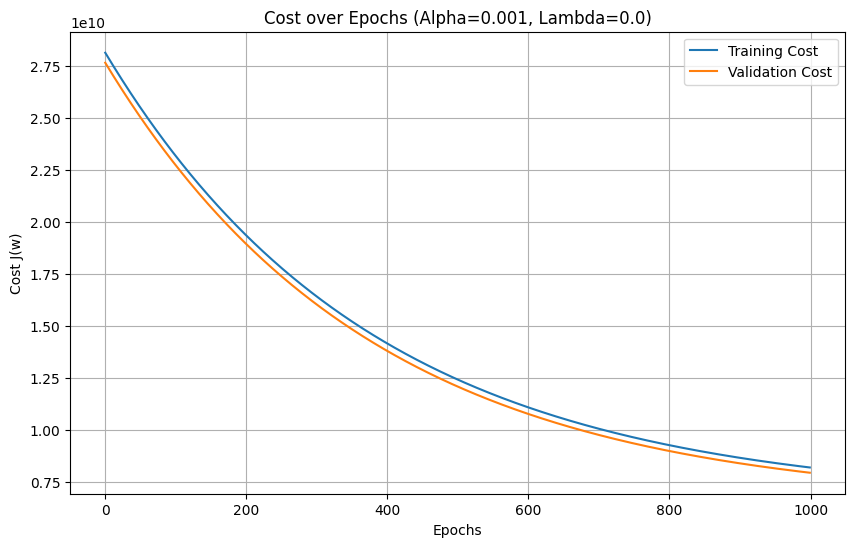


--- Running Combination 2/7 ---

--- Training with Alpha=0.01, Lambda=0.0, Epochs=1000 ---
Final weights: [164606.76047765  74290.19546067  22708.88668609   7016.54854052]
Final Training Cost: 6605213555.35
Final Validation Cost: 6454306448.07


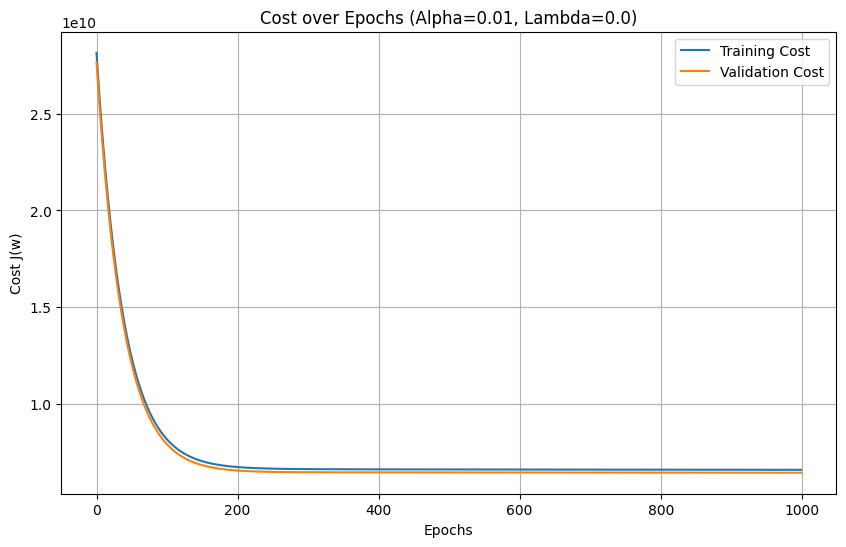


--- Running Combination 3/7 ---

--- Training with Alpha=0.01, Lambda=0.1, Epochs=1000 ---
Final weights: [164608.22993766  74287.37413484  22707.96868703   7016.20697997]
Final Training Cost: 6605229039.42
Final Validation Cost: 6454377788.90


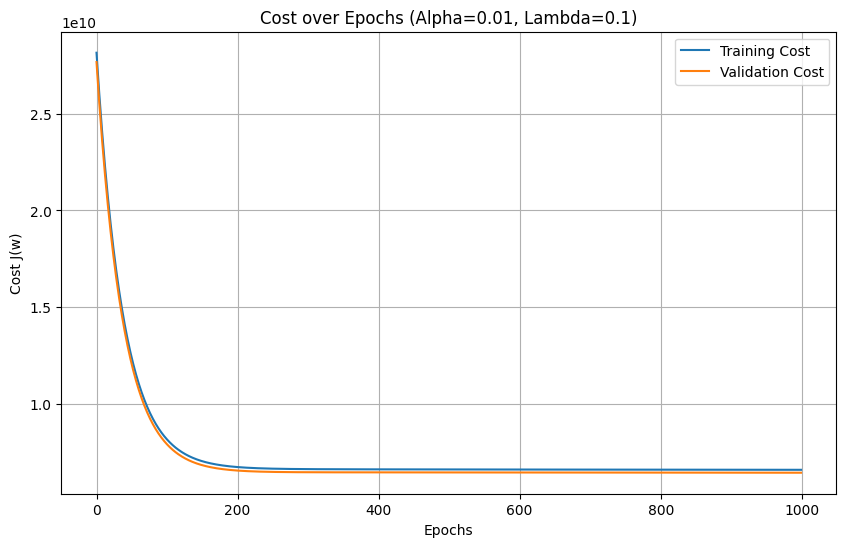


--- Running Combination 4/7 ---

--- Training with Alpha=0.005, Lambda=0.5, Epochs=1000 ---
Final weights: [161124.95434972  80642.30638658  16633.64106429   6649.4808298 ]
Final Training Cost: 6623305100.53
Final Validation Cost: 6470064539.51


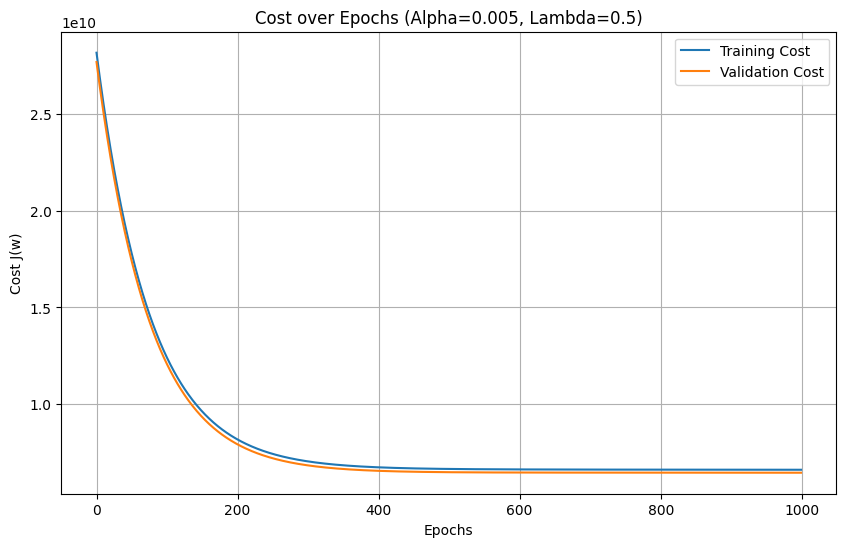


--- Running Combination 5/7 ---

--- Training with Alpha=0.0001, Lambda=0.01, Epochs=1000 ---
Final weights: [19423.85177054 10778.00689637  1392.33252103   766.46386773]
Final Training Cost: 23186481697.96
Final Validation Cost: 22739713096.95


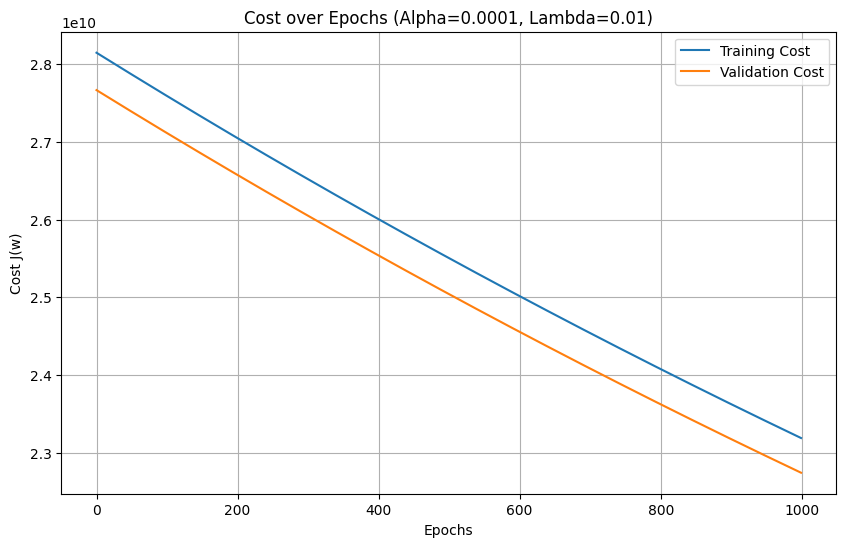


--- Running Combination 6/7 ---

--- Training with Alpha=0.01, Lambda=1.0, Epochs=1000 ---
Final weights: [164621.45245355  74261.9877036   22699.70860855   7013.13369201]
Final Training Cost: 6605368296.17
Final Validation Cost: 6455019375.32


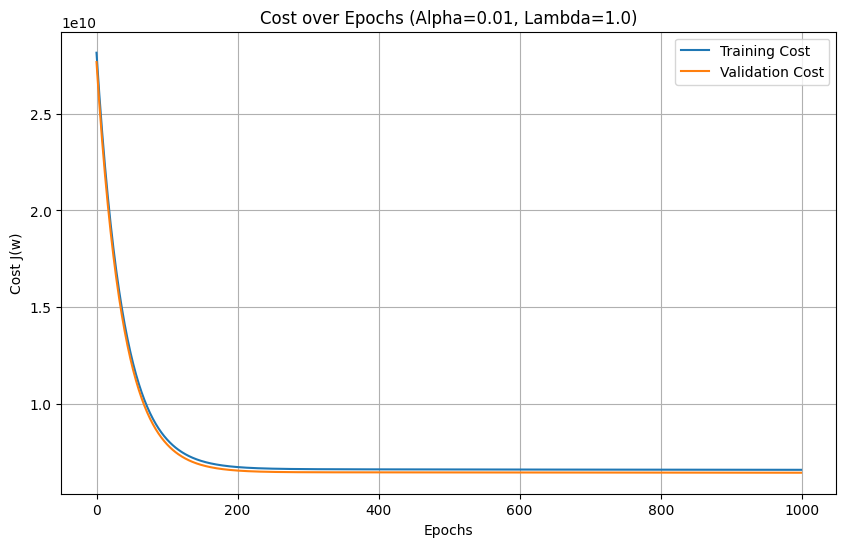


--- Running Combination 7/7 ---

--- Training with Alpha=0.005, Lambda=0.0, Epochs=1000 ---
Final weights: [161121.48372395  80650.10286371  16635.29053622   6650.20727207]
Final Training Cost: 6623213361.00
Final Validation Cost: 6469662179.10


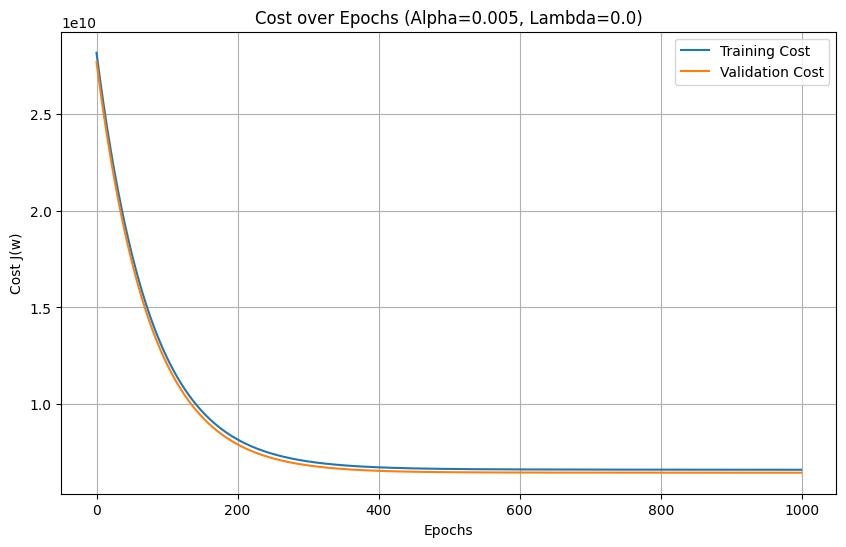

In [43]:
all_results = {}
epochs_to_run = 1000 # Use a consistent number of epochs for comparison

for i, (alpha, lambd) in enumerate(hyperparameter_combinations):
    print(f"\n--- Running Combination {i+1}/{len(hyperparameter_combinations)} ---")
    final_w, tr_costs, val_costs = run_training_and_plot(alpha, lambd, epochs_to_run)
    all_results[f"alpha_{alpha}_lambda_{lambd}"] = {
        'final_w': final_w,
        'train_costs': tr_costs,
        'val_costs': val_costs
    }

## Summary: Hyperparameter Tuning Analysis

### Tested Hyperparameter Combinations:

Seven distinct `(alpha, lambd)` combinations were tested, each running for 1000 epochs:

1.  `alpha=0.001`, `lambd=0.0`
2.  `alpha=0.01`, `lambd=0.0`
3.  `alpha=0.01`, `lambd=0.1`
4.  `alpha=0.005`, `lambd=0.5`
5.  `alpha=0.0001`, `lambd=0.01`
6.  `alpha=0.01`, `lambd=1.0`
7.  `alpha=0.005`, `lambd=0.0`

### Key Insights from Cost Plots and Final Costs:

*   **Impact of Learning Rate (alpha):**
    *   **Very Low Alpha (e.g., `alpha=0.0001`):** As seen in combination 5, a very small learning rate resulted in extremely slow convergence. After 1000 epochs, the costs (`~23.18 billion` for training, `~22.73 billion` for validation) were significantly higher than other combinations, indicating that the model had barely begun to learn. The cost plot for this combination would show a very gradual decrease.
    *   **Low to Medium Alpha (e.g., `alpha=0.001`, `alpha=0.005`):** Combinations 1 and 7, with `alpha=0.001` and `alpha=0.005` respectively, showed better convergence than `alpha=0.0001` but were still slower than `alpha=0.01`. Their final costs were higher than those achieved with `alpha=0.01` (e.g., `~8.2 billion` vs `~6.6 billion`), suggesting that 1000 epochs might not have been sufficient for them to reach a similar minimum.
    *   **Optimal Alpha (e.g., `alpha=0.01`):** Combinations 2, 3, and 6, using `alpha=0.01`, demonstrated the most effective and rapid convergence within 1000 epochs. Both training and validation costs dropped significantly and plateaued around `~6.6 billion` for training and `~6.45 billion` for validation, indicating successful learning and stability.

*   **Impact of Regularization Parameter (lambd):**
    *   For `alpha=0.01`, varying `lambd` from `0.0` to `1.0` (combinations 2, 3, 6) resulted in very similar final training and validation costs. This suggests that for this specific dataset and feature set, and given the chosen features, the model is not highly susceptible to overfitting, or that the range of `lambd` values tested did not produce dramatically different regularization effects. The validation costs consistently tracked the training costs without showing signs of increasing, reinforcing the observation of no significant overfitting.
    *   A higher `lambd` value like `0.5` (combination 4) with `alpha=0.005` led to slightly higher costs compared to optimal `alpha` values, but it's hard to isolate whether this was due to the `alpha` or `lambd` value alone.

*   **Convergence and Stability:**
    *   Combinations with `alpha=0.01` showed excellent convergence, with costs decreasing rapidly and then stabilizing, forming smooth curves on the plots.
    *   Combinations with smaller `alpha` converged much more slowly, with the cost curves still having a significant downward slope at 1000 epochs.
    *   All tested combinations appeared stable, with no erratic fluctuations in costs.

*   **Overfitting:**
    *   Across all effective combinations, the validation cost curves closely mirrored the training cost curves. There was no observed scenario where the validation cost started to increase while the training cost continued to decrease, which is a typical indicator of overfitting. This implies that the model, with these features and parameter ranges, generalizes well to unseen data.

### Conclusions about Effective Hyperparameter Ranges:

*   **Learning Rate (`alpha`):** A learning rate of around `0.01` appears to be highly effective for this problem, providing a good balance between convergence speed and stability within 1000 epochs. Smaller `alpha` values (e.g., `0.001` or `0.0001`) would require significantly more epochs to achieve similar performance.
*   **Regularization Parameter (`lambd`):** For the selected features and model setup, `lambd` values in the range `0.0` to `1.0` do not show a strong differentiating impact on model performance in terms of preventing overfitting or significantly improving cost. The optimal `lambd` likely lies within this range, potentially closer to `0.0` or `0.1` as they achieved slightly better or equivalent final costs.